In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. IMPORTATION DU DATASET

In [5]:
zion=pd.read_csv('INOHA-DataScience-M2/epidemioes_RDC.csv')
zion

,RDC,Cas_Suspects,Cas_Confirmes
0,RDC,112,52
1,RDC,189,85
2,RDC,102,50
3,RDC,24,18
4,RDC,116,50
...,...,...,...
95,RDC,166,74
96,RDC,24,19
97,RDC,54,29
98,RDC,74,41


In [7]:
from sklearn.model_selection import train_test_split

x=zion['Cas_Suspects']
y=zion['Cas_Confirmes']

2. LE GRAPHIQUE DE NUAGE DE POINTS  

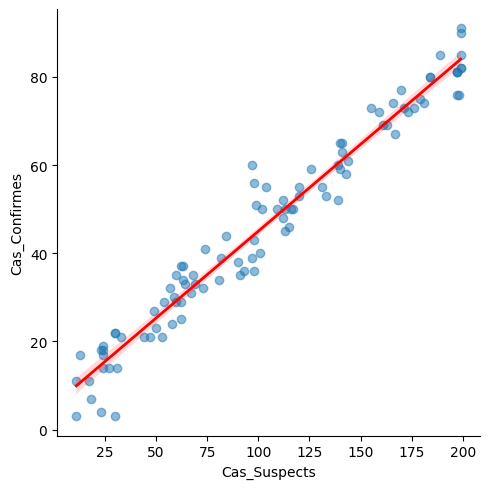

In [27]:
sns.lmplot(x='Cas_Suspects', y='Cas_Confirmes', data =zion,
           scatter_kws={'alpha':0.5},
           line_kws={'color':'red', 'linewidth':2})

In [8]:
x_train,x_test,y_train,y_test= train_test_split(x, y, test_size=0.2, random_state=10)

In [9]:
x_train

90     33
70    141
50    141
44     60
76     63
     ... 
89     62
28     31
64    184
15    161
9     131
Name: Cas_Suspects, Length: 80, dtype: int64

In [10]:
x_train = np.array(x_train).reshape(-1,1)
x_test = np.array(x_test).reshape(-1,1)

2. MODELE DE REGRESSION LINAIRE

In [11]:
from sklearn.linear_model import LinearRegression

model_RLS = LinearRegression()

model_RLS.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
B0 = model_RLS.intercept_
B0

np.float64(6.863749408105271)

In [14]:
B1= model_RLS.coef_
B1

array([0.38323228])

In [16]:
y_pred = model_RLS.predict(x_test).round(2)
y_pred

array([11.08, 50.17, 60.52, 77.38, 41.35, 16.06, 72.4 , 31.39, 83.13,
       29.47, 45.95, 79.29, 52.85, 15.68, 70.48, 50.94, 82.36, 72.01,
       45.57, 18.36])

In [17]:
y_test

19    11
14    45
43    59
37    80
66    38
3     18
79    73
41    33
38    91
68    30
2     50
1     85
60    53
53     4
95    74
74    46
92    81
26    77
59    40
46     3
Name: Cas_Confirmes, dtype: int64

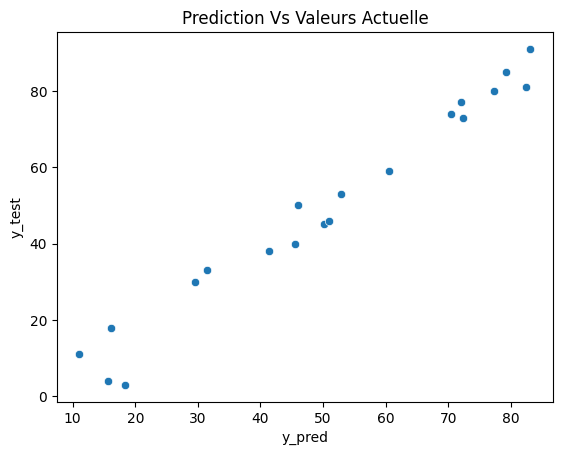

In [18]:
sns.scatterplot(x=y_pred.flatten(), y=y_test)
plt.xlabel('y_pred')
plt.ylabel('y_test')
plt.title('Prediction Vs Valeurs Actuelle')
plt.show()

3. METRIQUES D'EVALUATION DE PERFORMANCE DU MODELE 

In [32]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math


print("MSE",mean_squared_error(y_test, y_pred))
print("MAE",mean_absolute_error(y_test, y_pred))
print("RMSE",math.sqrt(mean_squared_error(y_test, y_pred)))
print("R2", r2_score(y_test, y_pred) )

MSE 31.600789999999996
MAE 4.130999999999999
RMSE 5.621457995929525
R2 0.956505541619784


Notre modèle explique 95.65 % de la variabilité de cas confirmés est expliqué par les nombres de cas suspects 

B0= 6.86 : il ya un seuil de 6.86 que nous ne parvenons pas à capter c'est à dire il ya le bruit de 6.86 cas sous notifiés
RMSE de 5.6 :
Une MAE de 4
 signifie qu'en moyenne, les prédictions s'écartent de 4 unités de la réalité. Un MAE plus proche de 0 indique un meilleur ajustement du modèle.
Il représente l'écart type des résidus. Un RMSE de 3 signifie que les erreurs du modèle sont typiquement de l'ordre de 3 unités par rapport à la valeur réelle. Un RMSE plus proche de 0 indique un meilleur ajustement.  

PREDICTION

In [28]:
y_pred_series = pd.Series(y_pred.flatten(), index=y_test.index)
results_zion = pd.DataFrame({'Cas_Confirmes': y_test, 'Valeur Predicte': y_pred_series})

results_zion['Diff ou Risidual'] = np.abs(results_zion['Cas_Confirmes'] - results_zion['Valeur Predicte'])
display(results_zion.head(15))

,Cas_Confirmes,Valeur Predicte,Diff ou Risidual
19,11,11.08,0.08
14,45,50.17,5.17
43,59,60.52,1.52
37,80,77.38,2.62
66,38,41.35,3.35
3,18,16.06,1.94
79,73,72.40,0.60
41,33,31.39,1.61
38,91,83.13,7.87
68,30,29.47,0.53


NameError: name 'r2' is not defined

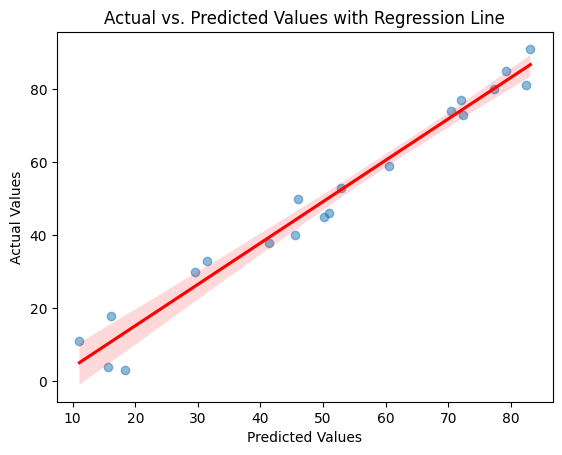

In [29]:
sns.regplot(x=y_pred.flatten(), y=y_test, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Values with Regression Line')

plt.text(0.05, 0.95, f'R2 Score: {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')


plt.text(0.05, 0.90, f'Regression Line: y = {B1[0]:.2f}x + {B0:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

mean_y_test = y_test.mean()
plt.text(0.05, 0.85, f'Mean of Actual Values: {mean_y_test:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.show()